### View-Based Learning using Compressive Sensing Induced Augmentation on Music

Compressive sensing admits powerful mathematical framework for the analysis of how compressible or recoverable information is under a manifold/sparse assumption. In this project, I wanted to explore how we can exploit the flexibility of a sensing operator, to induce augmentation for view-based learning on a non-trivial dataset. 

This notebook is a simple interface for existing CLI hooks in the codebase. It imports major API calls from each module so that the pipeline design and analysis of experiments are primary as you view the notebook. More detailed explanations of the codebase can be seen in the README.md.  

The FMA small dataset uses 8 Genres: Electronic, Experimental, Folk, Hip-Hop, Instrumental, International, Pop, Rock. It was determined early that the inclusion of Pop, even during invariance training, is a major confound. This is because Pop lacks the same audio identity that the other 7 genres have. Thus it is removed from the study.

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from preprocess import run_decode_audio, run_mel, run_audio_unzip

In [ ]:
# Regenerate .npy files from .mp3 (using ffmpeg) 
run_decode_audio("preprocesss/data/fma_small") 

In [ ]:
# Regenerate mel-spectrograms from audio signal for baseline/visualization
run_mel("preprocess/data/fma_small") 

[preprocess] mel: converting /home/andrew/Projects/spiky/preprocess/data/fma_small
START data_dir=/home/andrew/Projects/spiky/preprocess/data/fma_small output_dir=/home/andrew/Projects/spiky/preprocess/data/fma_small_mel files=8000


[mel] processed=32 skipped=0 total=8000
[mel] processed=320 skipped=0 total=8000
[mel] processed=640 skipped=0 total=8000
[mel] processed=960 skipped=0 total=8000
[mel] processed=1280 skipped=0 total=8000


In [ ]:
# Unzip .npy and mel-spectrogram .pt from zip 
run_audio_unzip("fma_small_decoded.zip", "preprocess/data/fma_small")

### Augmentation Visualization 

For each genre, find the training track whose embedding lies closest to the genre centroid, then display its mel-spectrogram under each augmentation type:
- DCT with low-energy bias subsampling
- DCT with uniform subsampling
- SRHT with random uniform
- Time-stretch and additive random gain (traditional method 'w2') 

In [2]:
from evaluation import find_centroid_tracks, build_showcase_data, plot_augmentation_showcase

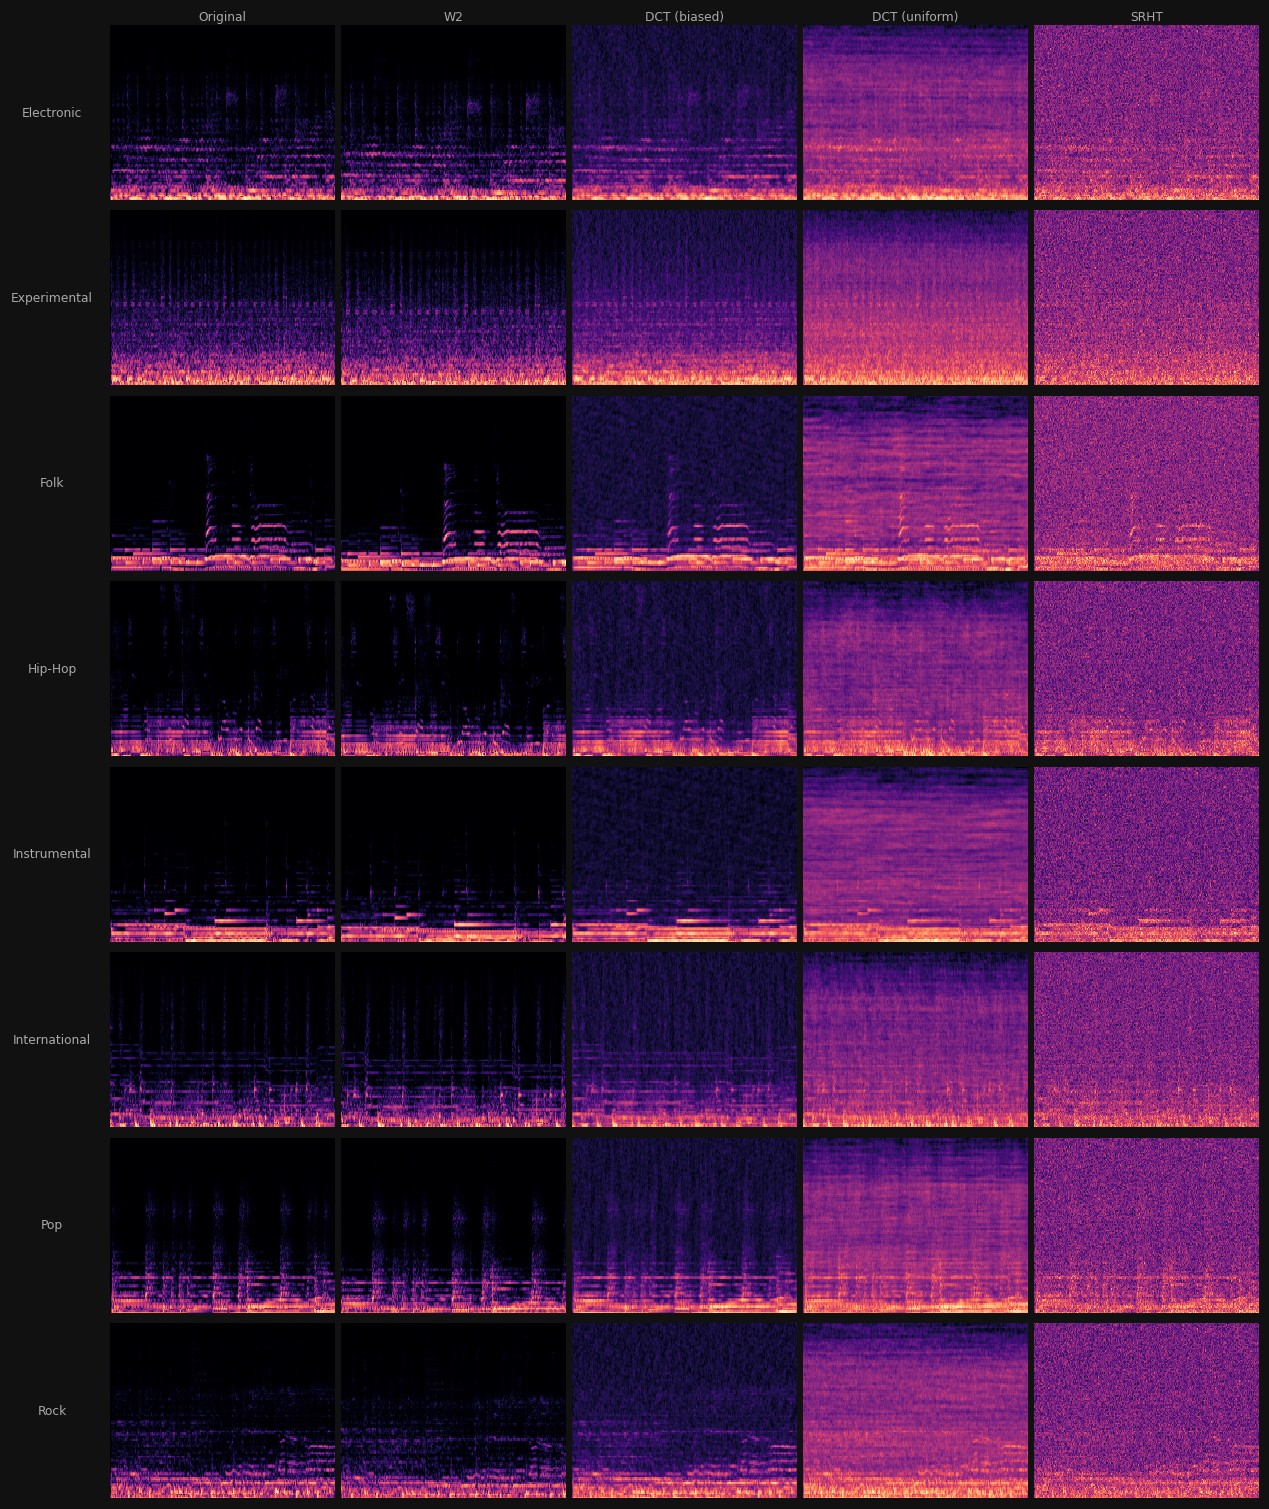

In [5]:
centroid_tracks = find_centroid_tracks(
    data_dir="preprocess/data/fma_small_mel",
    audio_root="preprocess/data",
)

showcase = build_showcase_data(
    centroid_tracks,
    audio_root="preprocess/data",
    ratio=50,
)

fig = plot_augmentation_showcase(showcase)
fig.savefig("evaluation/images/augmentation_showcase.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### pSNR and Alignment vs Compression Ratio

Signal-level quality (pSNR) and alignment (cosine similarity) between original and reconstructed mel-spectrograms across biased DCT, uniform DCT, and SRHT sampling strategies.

In [3]:
from evaluation import compute_psnr_alignment_sweep, plot_psnr_alignment_suite

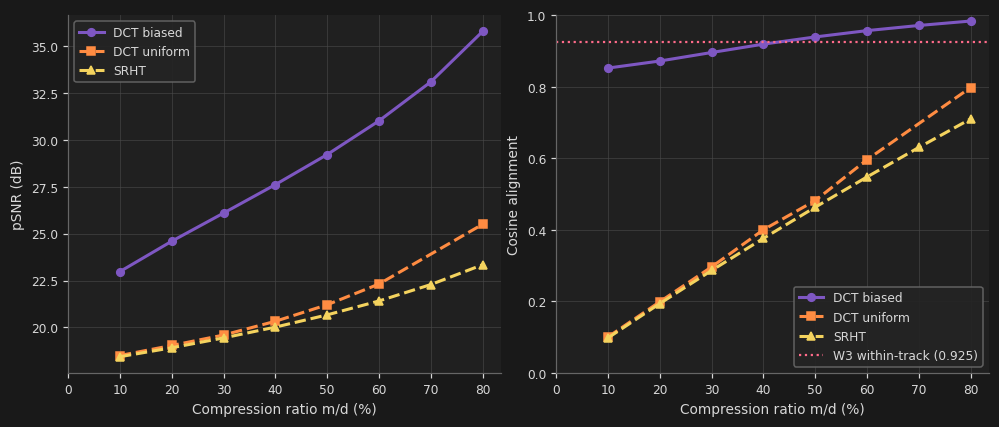

In [4]:
results_geom = compute_psnr_alignment_sweep(
    data_dir="preprocess/data/fma_small_mel",
    audio_root="preprocess/data",
    ratios_biased=[10, 20, 30, 40, 50, 60, 70, 80],
    ratios_uniform=[10, 20, 30, 40, 50, 60, 80],
    n_samples=512,
)

fig = plot_psnr_alignment_suite(results_geom)
fig.savefig("evaluation/images/psnr_alignment_suite.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Barlow Twins Training

TODO

In [3]:
from representation import run_wave_barlow

In [ ]:
ratios = [10, 20, 40, 60]

for ratio in ratios:
    run_wave_barlow(ratio=ratio, exclude_genres=["Pop"])

In [ ]:
for ratio in ratios:
    run_wave_barlow(ratio=ratio, uniform=True, exclude_genres=["Pop"])

In [ ]:
for ratio in [20, 40, 60]:
    run_wave_barlow(ratio=ratio, srht=True, exclude_genres=["Pop"])

In [ ]:
for policy in ["w2", "w3", "w4"]:
    run_wave_barlow(policy=policy, exclude_genres=["Pop"])

In [ ]:
from representation import run_supcon

run_supcon(exclude_genres=["Pop"])

In [ ]:
from evaluation import run_linear_probe, run_probe_suite, load_mel_embeddings, plot_f1_ci_vs_ratio

In [ ]:
DATA_DIR = "preprocess/data/fma_small_mel"

df = pd.read_parquet("representation/data/wave_barlow_fma_small.parquet")
df = pd.concat([df, load_mel_embeddings(DATA_DIR)], ignore_index=True)

probe_cache = run_probe_suite(df, exclude_genres=["Pop"])

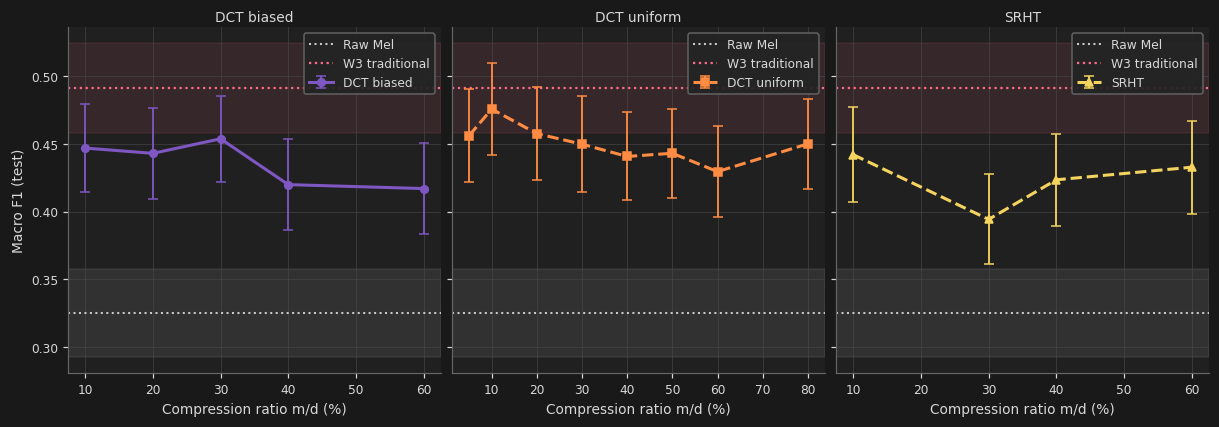

In [5]:
fig = plot_f1_ci_vs_ratio(probe_cache)
fig.savefig("evaluation/images/f1_ci_vs_ratio.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()